# P2.4 · Token and position embeddings

**Maths fundamentals for transformers · Tiny Transformer**

A repeated character needs a representation of where it appears as well as which character it is.

**You will be able to:** This model learns a vector for each position and adds it to the character’s learned token vector.

This notebook runs independently in Jupyter or Google Colab on a CPU. Download it from the course, then use **Colab → File → Upload notebook**. Public publication target: https://github.com/gkiri/tiny_repo. All required numerical examples are included.

The model connection uses the same **9,417-parameter transformer** as Unit 1: 65 characters, 32 positions, 28 features, two heads, learned position embeddings, LayerNorm and GELU.

In [1]:
#@title Setup: CPU, local Jupyter or Google Colab { display-mode: "form" }
# This notebook is self-contained. No account, secret, repository clone or GPU is required.
import sys, math, json, base64, zlib, hashlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (7, 3), "figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
print("Ready on CPU · PyTorch", torch.__version__)
print("All example data is included in this notebook.")

Ready on CPU · PyTorch 2.10.0+cpu
All example data is included in this notebook.


## Predict first

How is a position embedding calculated?

Write down your prediction before running the calculation.

For position 1, add token vector [2, 0, 1] and position vector [0.4, 0.5, 0.6].

## Work the numbers

1. Same character → same token vector [2, 0, 1]

2. Position 0 → [0.1, 0.2, 0.3]

3. Position 1 → [0.4, 0.5, 0.6]

4. Add: [2.1, 0.2, 1.3] versus [2.4, 0.5, 1.6]

$$x_t=E[\mathrm{id}_t]+P[t],\quad E\in\mathbb R^{65\times28},\ P\in\mathbb R^{32\times28}$$

These small numbers are **Illustrative**. Each symbol names a quantity already shown above.

In [2]:
#@title Explicit teaching functions (expand to inspect) { display-mode: "form" }
"""P2's explicit calculations. Each function is checked against an independent PyTorch operation.

Rows use the final axis for features. Linear weights use PyTorch's [out, in] convention.
These readable implementations teach the operations; the reference model remains unchanged.
"""
import math
import torch


def dot(x, y):
    if x.shape != y.shape or x.ndim != 1:
        raise ValueError("dot needs two vectors of the same length")
    return (x * y).sum()


def linear(x, weight, bias):
    return x @ weight.transpose(-2, -1) + bias


def embeddings(ids, token_table, position_table):
    positions = torch.arange(ids.shape[-1], device=ids.device)
    if ids.shape[-1] > position_table.shape[0]:
        raise ValueError("the position table is shorter than the input")
    return token_table[ids] + position_table[positions]


def layernorm(x, gamma, beta, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    variance = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
    return (x - mean) / torch.sqrt(variance + eps) * gamma + beta


def softmax(scores, temperature=1.0):
    if temperature <= 0 or not math.isfinite(temperature):
        raise ValueError("temperature must be finite and positive")
    if torch.isnan(scores).any() or torch.isposinf(scores).any() or torch.isneginf(scores).all(dim=-1).any():
        raise ValueError("each score row needs a finite entry, with no NaN or positive infinity")
    scaled = scores / temperature
    shifted = scaled - scaled.max(dim=-1, keepdim=True).values
    positive = torch.exp(shifted)
    return positive / positive.sum(dim=-1, keepdim=True)


def attention(q, k, v):
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    allowed = torch.ones(scores.shape[-2:], dtype=torch.bool, device=q.device).tril()
    masked = scores.masked_fill(~allowed, float("-inf"))
    shares = softmax(masked)
    return shares @ v, shares, masked


def gelu(x):
    cdf = 0.5 * (1 + torch.erf(x / math.sqrt(2)))
    return x * cdf


def residual(x, update):
    if x.shape != update.shape:
        raise ValueError("a residual update must have the same shape as its input")
    return x + update


def cross_entropy(logits, targets):
    log_prob = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    correct = log_prob.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return -correct.mean()


def tiny_loss(w):
    """One adjustable logit: target 0, logits [2*w, 1, 0]."""
    z = torch.stack((2 * w, torch.ones_like(w), torch.zeros_like(w)))
    return cross_entropy(z.unsqueeze(0), torch.tensor([0], device=w.device))


def finite_difference(f, x, step=1e-5):
    return (f(x + step) - f(x - step)) / (2 * step)


def adamw_step(parameter, gradient, first, second, step, lr=0.003,
               betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
    """One AdamW update, including moment bias correction and decoupled weight decay."""
    beta1, beta2 = betas
    first = beta1 * first + (1 - beta1) * gradient
    second = beta2 * second + (1 - beta2) * gradient.square()
    first_hat = first / (1 - beta1 ** step)
    second_hat = second / (1 - beta2 ** step)
    parameter = parameter * (1 - lr * weight_decay) - lr * first_hat / (second_hat.sqrt() + eps)
    return parameter, first, second

print("Explicit functions loaded; each is independently tested against PyTorch.")

Explicit functions loaded; each is independently tested against PyTorch.


## Implement and verify

Read each line, predict its output, then run it. The explicit calculation and the PyTorch operation should agree.

In [3]:
E = torch.tensor([[2., 0., 1.], [1., -1., 0.]])
P = torch.tensor([[.1, .2, .3], [.4, .5, .6]])
ids = torch.tensor([0, 0])
x = E[ids] + P[torch.arange(len(ids))]
print("same token twice", E[ids].tolist())
print("different positions", x.tolist())
torch.testing.assert_close(x, F.embedding(ids, E) + F.embedding(torch.arange(2), P))

same token twice [[2.0, 0.0, 1.0], [2.0, 0.0, 1.0]]
different positions [[2.0999999046325684, 0.20000000298023224, 1.2999999523162842], [2.4000000953674316, 0.5, 1.600000023841858]]


## See it and change one thing

The plot is generated by the code. Change one input and predict how the picture will change before running it again.

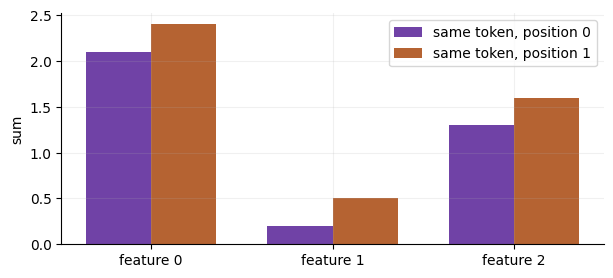

In [4]:
E = np.array([2., 0., 1.]); P = np.array([[.1,.2,.3],[.4,.5,.6]])
i=np.arange(3)
plt.bar(i-.18,E+P[0],.36,label="same token, position 0",color="#7042a6")
plt.bar(i+.18,E+P[1],.36,label="same token, position 1",color="#b56332")
plt.xticks(i,["feature 0","feature 1","feature 2"]); plt.ylabel("sum"); plt.legend(); plt.show()

## Find it in the transformer

The following values were exported at full precision from the pinned Unit 1 checkpoint. Crops are for display; complete vectors are used in calculations.

Recorded input: `You taught me language; and my p`.

Reference lesson: **inside-embeddings**.

In [5]:
#@title Recorded model fixture (included; no download) { display-mode: "form" }
recorded = json.loads('{"same_char":"a","same_positions":[5,15],"token_examples":[[-0.13883715867996216,0.10435182601213455,-0.33557215332984924,-0.6250741481781006,-0.12011069804430008,0.1229717954993248,0.22046594321727753,0.8754044771194458,-0.37901702523231506,-0.3479589819908142,0.5128963589668274,-0.8230023384094238,-0.05763336643576622,-0.14748625457286835,0.008741425350308418,0.03188542276620865,-0.3272736370563507,-0.4601448178291321,0.2835898995399475,0.12829208374023438,-0.11668217927217484,-0.6397911906242371,0.7370946407318115,0.4275597035884857,0.09910508245229721,-0.22824956476688385,-0.0698409453034401,0.27558600902557373],[-0.13883715867996216,0.10435182601213455,-0.33557215332984924,-0.6250741481781006,-0.12011069804430008,0.1229717954993248,0.22046594321727753,0.8754044771194458,-0.37901702523231506,-0.3479589819908142,0.5128963589668274,-0.8230023384094238,-0.05763336643576622,-0.14748625457286835,0.008741425350308418,0.03188542276620865,-0.3272736370563507,-0.4601448178291321,0.2835898995399475,0.12829208374023438,-0.11668217927217484,-0.6397911906242371,0.7370946407318115,0.4275597035884857,0.09910508245229721,-0.22824956476688385,-0.0698409453034401,0.27558600902557373]],"position_examples":[[-0.26870301365852356,0.020484399050474167,0.05604198947548866,-0.02143819071352482,-0.14290615916252136,-0.1392291933298111,0.275768518447876,0.0906393826007843,-0.09957858920097351,-0.18644586205482483,-0.043470971286296844,-0.3385472893714905,0.03560853749513626,-0.06560705602169037,-0.30004262924194336,0.06842037290334702,-0.18653573095798492,-0.10458778589963913,-0.035718876868486404,-0.037205129861831665,-0.22280025482177734,-0.11300672590732574,-0.22787772119045258,-0.14037083089351654,0.11773500591516495,-0.35806792974472046,0.46958765387535095,-0.033421751111745834],[-0.23356974124908447,0.09725794196128845,0.14808350801467896,0.039680562913417816,-0.033083848655223846,-0.09630876034498215,-0.02187993936240673,0.22608870267868042,-0.07333064079284668,-0.14756223559379578,0.011451024562120438,-0.31046155095100403,0.14691050350666046,0.04363670572638512,0.010434743016958237,0.10975727438926697,-0.12358302623033524,-0.03622062876820564,0.01062281709164381,0.07603459060192108,-0.04485839232802391,-0.06771834194660187,-0.15889719128608704,-0.09507431089878082,0.23046943545341492,-0.37011435627937317,0.06369759142398834,0.049044568091630936]],"x_examples":[[-0.4075401723384857,0.12483622133731842,-0.2795301675796509,-0.6465123295783997,-0.26301684975624084,-0.016257397830486298,0.4962344765663147,0.9660438299179077,-0.4785956144332886,-0.5344048738479614,0.46942538022994995,-1.1615495681762695,-0.02202482894062996,-0.21309331059455872,-0.2913011908531189,0.10030579566955566,-0.5138093829154968,-0.5647326111793518,0.2478710263967514,0.09108695387840271,-0.3394824266433716,-0.7527979016304016,0.5092169046401978,0.28718888759613037,0.21684008836746216,-0.5863174796104431,0.39974671602249146,0.2421642541885376],[-0.37240689992904663,0.2016097605228424,-0.1874886453151703,-0.5853936076164246,-0.15319454669952393,0.02666303515434265,0.19858600199222565,1.1014931201934814,-0.45234766602516174,-0.49552121758461,0.5243473649024963,-1.1334638595581055,0.08927713334560394,-0.10384954512119293,0.019176168367266655,0.14164268970489502,-0.45085665583610535,-0.4963654577732086,0.2942127287387848,0.20432667434215546,-0.16154056787490845,-0.7075095176696777,0.5781974792480469,0.3324853777885437,0.3295745253562927,-0.5983639359474182,-0.006143353879451752,0.32463058829307556]]}')
print("Recorded: prompter-r1; input: You taught me language; and my p")

Recorded: prompter-r1; input: You taught me language; and my p


In [6]:
e=torch.tensor(recorded["token_examples"]);p=torch.tensor(recorded["position_examples"]);out=torch.tensor(recorded["x_examples"]);torch.testing.assert_close(e+p,out);torch.testing.assert_close(e[0],e[1]);print("same character",recorded["same_char"],"positions",recorded["same_positions"]);print("first 4 coordinates of sums",out[:,:4].tolist())

same character a positions [5, 15]
first 4 coordinates of sums [[-0.4075401723384857, 0.12483622133731842, -0.2795301675796509, -0.6465123295783997], [-0.37240689992904663, 0.2016097605228424, -0.1874886453151703, -0.5853936076164246]]


### How are the learned position values obtained?

The index chooses a vector, not a sine formula. The actual model initializes embeddings with `nn.init.normal_(weight, mean=0, std=0.02)`. Training updates them through gradients of next-character loss. At inference they are fixed. The miniature example below demonstrates that gradient connection. Sinusoidal encodings and RoPE are separate positional methods; this model uses neither.

In [7]:
position_table=torch.nn.Embedding(2,3)
optimizer=torch.optim.SGD(position_table.parameters(),lr=.1)
before=position_table.weight.detach().clone()
# Illustrative objective to expose the selected entry's gradient, not the model's training loss.
loss=position_table(torch.tensor([1])).square().sum()
optimizer.zero_grad();loss.backward();optimizer.step()
print("unselected entry unchanged",torch.equal(before[0],position_table.weight[0]))
print("selected entry changed",not torch.equal(before[1],position_table.weight[1]))

unselected entry unchanged True
selected entry changed True


## A common trap

The position index selects a vector; it is not multiplied by the token ID. Sinusoidal encodings and RoPE are other methods, not this model’s computation.

### ✋ Your turn

For position 1, add token vector [2, 0, 1] and position vector [0.4, 0.5, 0.6].

In [8]:
answer = None  # TODO: make a prediction, then enter your answer

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert torch.allclose(torch.tensor(answer), torch.tensor([2.4, .5, 1.6])), 'Revisit the worked calculation above.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [9]:
#@title Show a solution { display-mode: "form" }
answer = [2.4, .5, 1.6]

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert torch.allclose(torch.tensor(answer), torch.tensor([2.4, .5, 1.6])), 'Revisit the worked calculation above.'
    print("✓ right:", answer)

✓ right: [2.4, 0.5, 1.6]


## Connect the dots

This model learns a vector for each position and adds it to the character’s learned token vector.

Next: mean, variance and layernorm.

To explain this operation to someone else, name its inputs, calculate one output, give its PyTorch equivalent, and point to its place in the transformer.